# Filtering Rows

In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 4, "display.max_rows", 10, "display.max_colwidth", 12)

## Introduction

## Calculating Boolean statistics

### How to do it...

In [2]:
movie = pd.read_csv("../data/movie.csv", index_col="movie_title")
movie[["duration"]].head()

,duration
movie_title,
Avatar,178.0
Pirates of the Caribbean: At World's End,169.0
Spectre,148.0
The Dark Knight Rises,164.0
Star Wars: Episode VII - The Force Awakens,NaN


In [3]:
movie_2_hours = movie["duration"] > 120
movie_2_hours.head(10)

movie_title
Avatar                                         True
Pirates of the Caribbean: At World's End       True
Spectre                                        True
The Dark Knight Rises                          True
Star Wars: Episode VII - The Force Awakens    False
John Carter                                    True
Spider-Man 3                                   True
Tangled                                       False
Avengers: Age of Ultron                        True
Harry Potter and the Half-Blood Prince         True
Name: duration, dtype: bool

In [4]:
movie_2_hours.sum()

1039

In [5]:
movie_2_hours.mean()

0.2113506916192026

In [6]:
movie["duration"].dropna().gt(120).mean()

0.21199755152009794

In [7]:
movie_2_hours.describe()

count      4916
unique        2
top       False
freq       3877
Name: duration, dtype: object

### How it works...

In [8]:
movie_2_hours.value_counts(normalize=True)

duration
False    0.788649
True     0.211351
Name: proportion, dtype: float64

In [9]:
movie_2_hours.astype(int).describe()

count    4916.000000
mean        0.211351
std         0.408308
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: duration, dtype: float64

### There's more...

In [10]:
actors = movie[["actor_1_facebook_likes", "actor_2_facebook_likes"]].dropna()
(actors["actor_1_facebook_likes"] > actors["actor_2_facebook_likes"]).mean()

0.9777687130328371

## Constructing multiple boolean conditions

### How to do it...

In [11]:
movie = pd.read_csv("../data/movie.csv", index_col="movie_title")

In [12]:
criteria1 = movie.imdb_score > 8
criteria2 = movie.content_rating == "PG-13"
criteria3 = (movie.title_year < 2000) | (movie.title_year > 2009)

In [13]:
criteria_final = criteria1 & criteria2 & criteria3
criteria_final.head()

movie_title
Avatar                                        False
Pirates of the Caribbean: At World's End      False
Spectre                                       False
The Dark Knight Rises                          True
Star Wars: Episode VII - The Force Awakens    False
dtype: bool

### How it works...

### There's more...

In [14]:
5 < 10 and 3 > 4

False

In [15]:
5 < 10 and 3 > 4

False

In [16]:
True and 3 > 4

False

In [17]:
True and False

False

In [18]:
False

False

In [19]:
try:
    movie.title_year < 2000 | movie.title_year > 2009
except TypeError as e:
    print("TypeError: ", e)
    print("use brackets to respect the order of preference (here python tries to compare an integer and a pandas Series : '2000 | movie.title_year'")

TypeError:  Cannot perform 'ror_' with a dtyped [float64] array and scalar of type [bool]
use brackets to respect the order of preference (here python tries to compare an integer and a pandas Series : '2000 | movie.title_year'


## Filtering with boolean arrays

### How to do it...

In [20]:
movie = pd.read_csv("../data/movie.csv", index_col="movie_title")
crit_a1 = movie.imdb_score > 8
crit_a2 = movie.content_rating == "PG-13"
crit_a3 = (movie.title_year < 2000) | (movie.title_year > 2009)
final_crit_a = crit_a1 & crit_a2 & crit_a3

In [21]:
crit_b1 = movie.imdb_score < 5
crit_b2 = movie.content_rating == "R"
crit_b3 = (movie.title_year >= 2000) & (movie.title_year <= 2010)
final_crit_b = crit_b1 & crit_b2 & crit_b3

In [22]:
final_crit_all = final_crit_a | final_crit_b
final_crit_all.head()

movie_title
Avatar                                        False
Pirates of the Caribbean: At World's End      False
Spectre                                       False
The Dark Knight Rises                          True
Star Wars: Episode VII - The Force Awakens    False
dtype: bool

In [23]:
movie[final_crit_all].head()

,color,director_name,...,aspect_ratio,movie_facebook_likes
movie_title,,,,,
The Dark Knight Rises,Color,Christop...,...,2.35,164000
The Avengers,Color,Joss Whedon,...,1.85,123000
Captain America: Civil War,Color,Anthony ...,...,2.35,72000
Guardians of the Galaxy,Color,James Gunn,...,2.35,96000
Interstellar,Color,Christop...,...,2.35,349000


In [24]:
movie.loc[final_crit_all].head()

,color,director_name,...,aspect_ratio,movie_facebook_likes
movie_title,,,,,
The Dark Knight Rises,Color,Christop...,...,2.35,164000
The Avengers,Color,Joss Whedon,...,1.85,123000
Captain America: Civil War,Color,Anthony ...,...,2.35,72000
Guardians of the Galaxy,Color,James Gunn,...,2.35,96000
Interstellar,Color,Christop...,...,2.35,349000


In [25]:
cols = ["imdb_score", "content_rating", "title_year"]
movie_filtered = movie.loc[final_crit_all, cols]
movie_filtered.head(10)

,imdb_score,content_rating,title_year
movie_title,,,
The Dark Knight Rises,8.5,PG-13,2012.0
The Avengers,8.1,PG-13,2012.0
Captain America: Civil War,8.2,PG-13,2016.0
Guardians of the Galaxy,8.1,PG-13,2014.0
Interstellar,8.6,PG-13,2014.0
Inception,8.8,PG-13,2010.0
The Martian,8.1,PG-13,2015.0
Town & Country,4.4,R,2001.0
Sex and the City 2,4.3,R,2010.0


### How it works...

In [26]:
try:
    movie.iloc[final_crit_all]
except ValueError as e:
    print("ValueError: ", e)
    print("movie.iloc[final_crit_all]")
    print("`.iloc` does not support boolean arrays, but it does work with NumPy arrays")
    print("movie.iloc[final_crit_all.to_numpy()]")
    display(movie.iloc[final_crit_all.to_numpy()])
    print("movie.iloc[final_crit_all.values]")
    display(movie.iloc[final_crit_all.values])


ValueError:  iLocation based boolean indexing cannot use an indexable as a mask
movie.iloc[final_crit_all]
`.iloc` does not support boolean arrays, but it does work with NumPy arrays
movie.iloc[final_crit_all.to_numpy()]


,color,director_name,...,aspect_ratio,movie_facebook_likes
movie_title,,,,,
The Dark Knight Rises,Color,Christop...,...,2.35,164000
The Avengers,Color,Joss Whedon,...,1.85,123000
Captain America: Civil War,Color,Anthony ...,...,2.35,72000
Guardians of the Galaxy,Color,James Gunn,...,2.35,96000
Interstellar,Color,Christop...,...,2.35,349000
...,...,...,...,...,...
The Young Unknowns,Color,Catherin...,...,NaN,4
Bled,Color,Christop...,...,1.85,128
Hoop Dreams,Color,Steve James,...,1.33,0


movie.iloc[final_crit_all.values]


,color,director_name,...,aspect_ratio,movie_facebook_likes
movie_title,,,,,
The Dark Knight Rises,Color,Christop...,...,2.35,164000
The Avengers,Color,Joss Whedon,...,1.85,123000
Captain America: Civil War,Color,Anthony ...,...,2.35,72000
Guardians of the Galaxy,Color,James Gunn,...,2.35,96000
Interstellar,Color,Christop...,...,2.35,349000
...,...,...,...,...,...
The Young Unknowns,Color,Catherin...,...,NaN,4
Bled,Color,Christop...,...,1.85,128
Hoop Dreams,Color,Steve James,...,1.33,0


### There's more...

In [27]:
final_crit_a2 = (
    (movie.imdb_score > 8)
    & (movie.content_rating == "PG-13")
    & ((movie.title_year < 2000) | (movie.title_year > 2009))
)
final_crit_a2.equals(final_crit_a)

True

## Comparing Row Filtering and Index Filtering

### How to do it...

In [28]:
college = pd.read_csv("../data/college.csv")
college[college["STABBR"] == "TX"].head()

,INSTNM,CITY,...,MD_EARN_WNE_P10,GRAD_DEBT_MDN_SUPP
3610,Abilene ...,Abilene,...,40200,25985
3611,Alvin Co...,Alvin,...,34500,6750
3612,Amarillo...,Amarillo,...,31700,10950
3613,Angelina...,Lufkin,...,26900,PrivacyS...
3614,Angelo S...,San Angelo,...,37700,21319.5


In [29]:
college2 = college.set_index("STABBR")
college2.loc["TX"].head()

,INSTNM,CITY,...,MD_EARN_WNE_P10,GRAD_DEBT_MDN_SUPP
STABBR,,,,,
TX,Abilene ...,Abilene,...,40200,25985
TX,Alvin Co...,Alvin,...,34500,6750
TX,Amarillo...,Amarillo,...,31700,10950
TX,Angelina...,Lufkin,...,26900,PrivacyS...
TX,Angelo S...,San Angelo,...,37700,21319.5


In [30]:
%timeit college[college['STABBR'] == 'TX']

804 μs ± 153 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [31]:
%timeit college2.loc['TX']

190 μs ± 26.3 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [32]:
%timeit college2 = college.set_index('STABBR')

536 μs ± 54.3 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


### How it works...

### There's more...

In [33]:
states = ["TX", "CA", "NY"]
college[college["STABBR"].isin(states)]

,INSTNM,CITY,...,MD_EARN_WNE_P10,GRAD_DEBT_MDN_SUPP
192,Academy ...,San Fran...,...,36000,35093
193,ITT Tech...,Rancho C...,...,38800,25827.5
194,Academy ...,Oakland,...,NaN,PrivacyS...
195,The Acad...,Huntingt...,...,28400,9500
196,Avalon S...,Alameda,...,21600,9860
...,...,...,...,...,...
7528,WestMed ...,Merced,...,NaN,15623.5
7529,Vantage ...,El Paso,...,NaN,9500
7530,SAE Inst...,Emeryville,...,NaN,9500
7533,Bay Area...,San Jose,...,NaN,PrivacyS...


In [34]:
college2.loc[states]

,INSTNM,CITY,...,MD_EARN_WNE_P10,GRAD_DEBT_MDN_SUPP
STABBR,,,,,
TX,Abilene ...,Abilene,...,40200,25985
TX,Alvin Co...,Alvin,...,34500,6750
TX,Amarillo...,Amarillo,...,31700,10950
TX,Angelina...,Lufkin,...,26900,PrivacyS...
TX,Angelo S...,San Angelo,...,37700,21319.5
...,...,...,...,...,...
NY,Briarcli...,Patchogue,...,38200,28720.5
NY,Jamestow...,Salamanca,...,NaN,12050
NY,Pratt Ma...,New York,...,40900,26691


## Selecting with unique and sorted indexes

### How to do it...

In [35]:
college = pd.read_csv("../data/college.csv")
college2 = college.set_index("STABBR")

# college2.index.is_monotonic_increasing
# Deprecated since version 1.5.0: is_monotonic is deprecated and will be removed in a future version. Use is_monotonic_increasing instead.

print(f"{college2.index.is_monotonic_increasing=}")
print(f"{college2.index.is_monotonic_decreasing=}")

college2.index.is_monotonic_increasing=False
college2.index.is_monotonic_decreasing=False


In [36]:
college3 = college2.sort_index()
print(f"{college3.index.is_monotonic_increasing=}")
print(f"{college3.index.is_monotonic_decreasing=}")

college3.index.is_monotonic_increasing=True
college3.index.is_monotonic_decreasing=False


In [37]:
%timeit college[college['STABBR'] == 'TX']

725 μs ± 75.9 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [38]:
%timeit college2.loc['TX']

173 μs ± 3.54 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [39]:
%timeit college3.loc['TX']

24.7 μs ± 51.8 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [40]:
college_unique = college.set_index("INSTNM")
college_unique.index.is_unique

True

In [41]:
college[college["INSTNM"] == "Stanford University"]

,INSTNM,CITY,...,MD_EARN_WNE_P10,GRAD_DEBT_MDN_SUPP
4217,Stanford...,Stanford,...,86000,12782


In [42]:
college_unique.loc["Stanford University"]

CITY                  Stanford
STABBR                      CA
HBCU                       0.0
MENONLY                    0.0
WOMENONLY                  0.0
                        ...   
PCTPELL                 0.1556
PCTFLOAN                0.1256
UG25ABV                 0.0401
MD_EARN_WNE_P10          86000
GRAD_DEBT_MDN_SUPP       12782
Name: Stanford University, Length: 26, dtype: object

In [43]:
college_unique.loc[["Stanford University"]]

,CITY,STABBR,...,MD_EARN_WNE_P10,GRAD_DEBT_MDN_SUPP
INSTNM,,,,,
Stanford University,Stanford,CA,...,86000,12782


In [44]:
%timeit college[college['INSTNM'] == 'Stanford University']

595 μs ± 125 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [45]:
%timeit college_unique.loc[['Stanford University']]

112 μs ± 4.76 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


### How it works...

### There's more...

In [46]:
college.index = college["CITY"] + ", " + college["STABBR"]
college = college.sort_index()
college.head()

,INSTNM,CITY,...,MD_EARN_WNE_P10,GRAD_DEBT_MDN_SUPP
"ARTESIA, CA",Angeles ...,ARTESIA,...,NaN,16850
"Aberdeen, SD",Presenta...,Aberdeen,...,35900,25000
"Aberdeen, SD",Northern...,Aberdeen,...,33600,24847
"Aberdeen, WA",Grays Ha...,Aberdeen,...,27000,11490
"Abilene, TX",Hardin-S...,Abilene,...,38700,25864


In [47]:
college.loc["Miami, FL"].head()

,INSTNM,CITY,...,MD_EARN_WNE_P10,GRAD_DEBT_MDN_SUPP
"Miami, FL",New Prof...,Miami,...,18700,8682
"Miami, FL",Manageme...,Miami,...,PrivacyS...,12182
"Miami, FL",Strayer ...,Miami,...,49200,36173.5
"Miami, FL",Keiser U...,Miami,...,29700,26063
"Miami, FL",George T...,Miami,...,38600,PrivacyS...


In [48]:
%%timeit
crit1 = college["CITY"] == "Miami"
crit2 = college["STABBR"] == "FL"
college[crit1 & crit2]

1.18 ms ± 121 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [49]:
%timeit college.loc['Miami, FL']

22.1 μs ± 36 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


## Translating SQL WHERE clauses

### How to do it...

In [50]:
employee = pd.read_csv("../data/employee.csv")
employee.sample(5)

,UNIQUE_ID,POSITION_TITLE,...,HIRE_DATE,JOB_DATE
1253,1253,INSPECTOR,...,2013-01-28,2013-01-28
40,40,FIRE FIG...,...,2014-06-21,2015-09-21
53,53,DIVISION...,...,1992-12-14,2014-06-07
871,871,POLICE O...,...,2007-06-25,2008-06-25
210,210,INSPECTOR,...,2001-05-25,2012-11-24


In [51]:
employee.dtypes

UNIQUE_ID              int64
POSITION_TITLE        object
DEPARTMENT            object
BASE_SALARY          float64
RACE                  object
EMPLOYMENT_TYPE       object
GENDER                object
EMPLOYMENT_STATUS     object
HIRE_DATE             object
JOB_DATE              object
dtype: object

In [52]:
employee.DEPARTMENT.value_counts().head()

DEPARTMENT
Houston Police Department-HPD     638
Houston Fire Department (HFD)     384
Public Works & Engineering-PWE    343
Health & Human Services           110
Houston Airport System (HAS)      106
Name: count, dtype: int64

In [53]:
employee.GENDER.value_counts()

GENDER
Male      1397
Female     603
Name: count, dtype: int64

In [54]:
employee.BASE_SALARY.describe()

count    1886.000000
mean     55767.93...
std      21693.70...
min      24960.00...
25%      40170.00...
50%      54461.00...
75%      66614.00...
max      275000.0...
Name: BASE_SALARY, dtype: float64

In [55]:
depts = ["Houston Police Department-HPD", "Houston Fire Department (HFD)"]
criteria_dept = employee.DEPARTMENT.isin(depts)
criteria_gender = employee.GENDER == "Female"
criteria_sal = (employee.BASE_SALARY >= 80000) & (employee.BASE_SALARY <= 120000)

In [56]:
criteria_final = criteria_dept & criteria_gender & criteria_sal

In [57]:
select_columns = ["UNIQUE_ID", "DEPARTMENT", "GENDER", "BASE_SALARY"]
employee.loc[criteria_final, select_columns].head()

,UNIQUE_ID,DEPARTMENT,GENDER,BASE_SALARY
61,61,Houston ...,Female,96668.0
136,136,Houston ...,Female,81239.0
367,367,Houston ...,Female,86534.0
474,474,Houston ...,Female,91181.0
513,513,Houston ...,Female,81239.0


### How it works...

### There's more...

In [58]:
criteria_sal = employee.BASE_SALARY.between(80_000, 120_000)

In [59]:
top_5_depts = employee.DEPARTMENT.value_counts().index[:5]
criteria = ~employee.DEPARTMENT.isin(top_5_depts)
employee[criteria]

,UNIQUE_ID,POSITION_TITLE,...,HIRE_DATE,JOB_DATE
0,0,ASSISTAN...,...,2006-06-12,2012-10-13
1,1,LIBRARY ...,...,2000-07-19,2010-09-18
4,4,ELECTRICIAN,...,1989-06-19,1994-10-22
18,18,MAINTENA...,...,2008-12-29,2008-12-29
32,32,SENIOR A...,...,1991-02-11,2016-02-13
...,...,...,...,...,...
1976,1976,SENIOR S...,...,2015-07-20,2016-01-30
1983,1983,ADMINIST...,...,2006-10-16,2006-10-16
1985,1985,TRUCK DR...,...,2013-06-10,2015-08-01
1988,1988,SENIOR A...,...,2013-01-23,2013-03-02


## Improving readability of boolean indexing with the query method

### How to do it...

In [60]:
employee = pd.read_csv("../data/employee.csv")
depts = ["Houston Police Department-HPD", "Houston Fire Department (HFD)"]
select_columns = ["UNIQUE_ID", "DEPARTMENT", "GENDER", "BASE_SALARY"]

In [61]:
try :
    employee.query("""DEPARTMENT in @depts
                    and GENDER == 'Female'
                    and 80000 <= BASE_SALARY <= 120000""")
except ValueError as e:
    print("ValueError: ", e)
    #qs = ("DEPARTMENT in @depts and GENDER == 'Female' and 80000 <= BASE_SALARY <= 120000")
    qs = (
        "DEPARTMENT in @depts  "
        "and GENDER == 'Female'  "
        "and 80000 <= BASE_SALARY <= 120000"
    )
    emp_filtered = employee.query(qs)
    display(emp_filtered[select_columns].head())

ValueError:  multi-line expressions are only valid in the context of data, use DataFrame.eval


,UNIQUE_ID,DEPARTMENT,GENDER,BASE_SALARY
61,61,Houston ...,Female,96668.0
136,136,Houston ...,Female,81239.0
367,367,Houston ...,Female,86534.0
474,474,Houston ...,Female,91181.0
513,513,Houston ...,Female,81239.0


### How it works...

### There's more...

In [62]:
top10_depts = employee.DEPARTMENT.value_counts().index[:10].tolist()
qs = "DEPARTMENT not in @top10_depts and GENDER == 'Female'"
employee_filtered2 = employee.query(qs)
employee_filtered2.head()

,UNIQUE_ID,POSITION_TITLE,...,HIRE_DATE,JOB_DATE
0,0,ASSISTAN...,...,2006-06-12,2012-10-13
73,73,ADMINIST...,...,2011-12-19,2013-11-23
96,96,ASSISTAN...,...,2013-06-10,2013-06-10
117,117,SENIOR A...,...,1998-03-20,2012-07-21
146,146,SENIOR S...,...,2014-03-17,2014-03-17


## Preserving Series size with the where method

### How to do it...

In [63]:
movie = pd.read_csv("../data/movie.csv", index_col="movie_title")
fb_likes = movie["actor_1_facebook_likes"].dropna()
fb_likes.head()

movie_title
Avatar                                         1000.0
Pirates of the Caribbean: At World's End      40000.0
Spectre                                       11000.0
The Dark Knight Rises                         27000.0
Star Wars: Episode VII - The Force Awakens      131.0
Name: actor_1_facebook_likes, dtype: float64

In [64]:
fb_likes.describe()
# seems to be highly skewed to the right with a few very large observations (more than an order of magnitude greater than the median)

count    4909.000000
mean     6494.488491
std      15106.98...
min         0.000000
25%       607.000000
50%       982.000000
75%      11000.00...
max      640000.0...
Name: actor_1_facebook_likes, dtype: float64

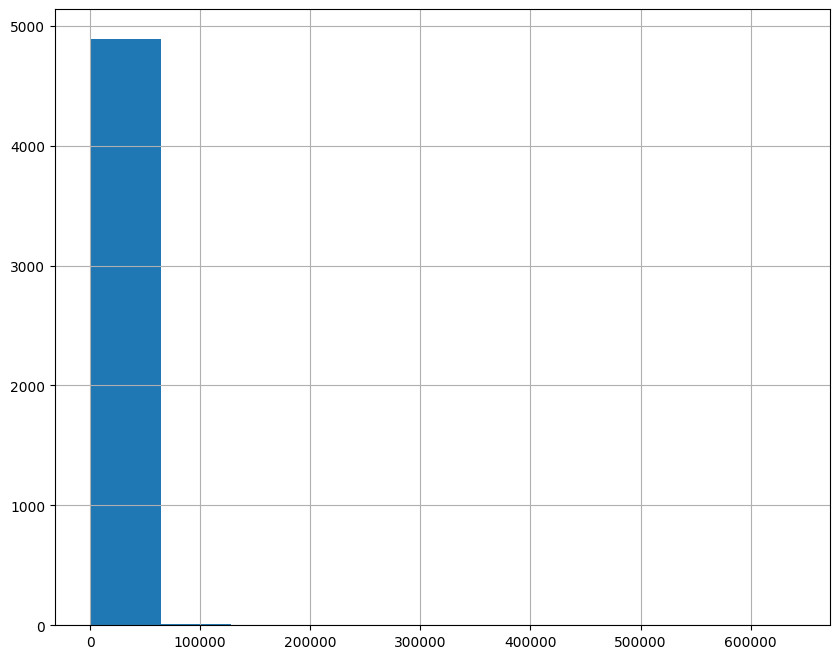

In [65]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
fb_likes.hist(ax=ax)
fig.savefig("/tmp/c7-hist.png", dpi=300)  # doctest: +SKIP

In [66]:
criteria_high = fb_likes < 20_000
criteria_high.mean().round(2) # 91% of the values are below 20k likes

0.91

In [67]:
fb_likes.where(criteria_high).head()

movie_title
Avatar                                         1000.0
Pirates of the Caribbean: At World's End          NaN
Spectre                                       11000.0
The Dark Knight Rises                             NaN
Star Wars: Episode VII - The Force Awakens      131.0
Name: actor_1_facebook_likes, dtype: float64

In [68]:
fb_likes.where(criteria_high, other=20000).head()

movie_title
Avatar                                         1000.0
Pirates of the Caribbean: At World's End      20000.0
Spectre                                       11000.0
The Dark Knight Rises                         20000.0
Star Wars: Episode VII - The Force Awakens      131.0
Name: actor_1_facebook_likes, dtype: float64

In [69]:
criteria_low = fb_likes > 300
fb_likes_cap = fb_likes.where(criteria_high, other=20_000).where(criteria_low, 300)
fb_likes_cap.head()

movie_title
Avatar                                         1000.0
Pirates of the Caribbean: At World's End      20000.0
Spectre                                       11000.0
The Dark Knight Rises                         20000.0
Star Wars: Episode VII - The Force Awakens      300.0
Name: actor_1_facebook_likes, dtype: float64

In [70]:
len(fb_likes), len(fb_likes_cap)

(4909, 4909)

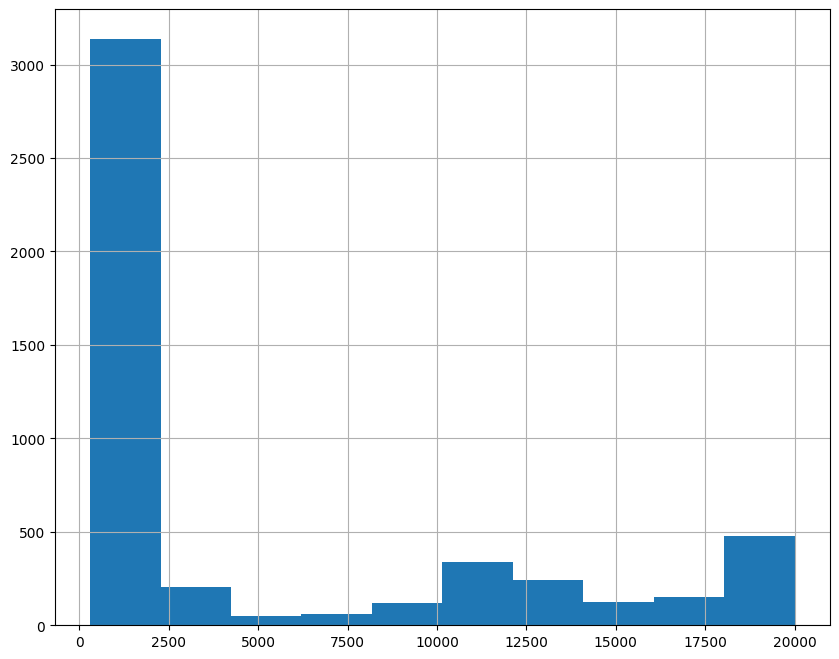

In [71]:
fig, ax = plt.subplots(figsize=(10, 8))
fb_likes_cap.hist(ax=ax)
fig.savefig("/tmp/c7-hist2.png", dpi=300)  # doctest: +SKIP

### How it works...

### There's more...

In [72]:
fb_likes_cap2 = fb_likes.clip(lower=300, upper=20000)
fb_likes_cap2.equals(fb_likes_cap)

True

## Masking DataFrame rows

### How to do it...

In [73]:
movie = pd.read_csv("../data/movie.csv", index_col="movie_title")
c1 = movie["title_year"] >= 2010
c2 = movie["title_year"].isna()
criteria = c1 | c2

In [74]:
movie.mask(criteria).head()

,color,director_name,...,aspect_ratio,movie_facebook_likes
movie_title,,,,,
Avatar,Color,James Ca...,...,1.78,33000.0
Pirates of the Caribbean: At World's End,Color,Gore Ver...,...,2.35,0.0
Spectre,NaN,NaN,...,NaN,NaN
The Dark Knight Rises,NaN,NaN,...,NaN,NaN
Star Wars: Episode VII - The Force Awakens,NaN,NaN,...,NaN,NaN


In [75]:
movie_mask = movie.mask(criteria).dropna(how="all")
movie_mask.head()

,color,director_name,...,aspect_ratio,movie_facebook_likes
movie_title,,,,,
Avatar,Color,James Ca...,...,1.78,33000.0
Pirates of the Caribbean: At World's End,Color,Gore Ver...,...,2.35,0.0
Spider-Man 3,Color,Sam Raimi,...,2.35,0.0
Harry Potter and the Half-Blood Prince,Color,David Yates,...,2.35,10000.0
Superman Returns,Color,Bryan Si...,...,2.35,0.0


In [76]:
movie_boolean = movie[movie["title_year"] < 2010]
movie_mask.equals(movie_boolean)

False

In [77]:
movie_mask.shape == movie_boolean.shape

True

In [78]:
movie_mask.dtypes == movie_boolean.dtypes

color                       True
director_name               True
num_critic_for_reviews      True
duration                    True
director_facebook_likes     True
                           ...  
title_year                  True
actor_2_facebook_likes      True
imdb_score                  True
aspect_ratio                True
movie_facebook_likes       False
Length: 27, dtype: bool

In [79]:
from pandas.testing import assert_frame_equal

assert_frame_equal(movie_boolean, movie_mask, check_dtype=False)

### How it works...

### There's more...

In [80]:
%timeit movie.mask(criteria).dropna(how='all')

4.22 ms ± 801 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [81]:
%timeit movie[movie['title_year'] < 2010]

647 μs ± 110 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


## Selecting with booleans, integer location, and labels

### How to do it...

In [82]:
movie = pd.read_csv("../data/movie.csv", index_col="movie_title")
c1 = movie["content_rating"] == "G"
c2 = movie["imdb_score"] < 4
criteria = c1 & c2

In [83]:
movie_loc = movie.loc[criteria]
movie_loc.head()

,color,director_name,...,aspect_ratio,movie_facebook_likes
movie_title,,,,,
The True Story of Puss'N Boots,Color,Jérôme D...,...,NaN,90
Doogal,Color,Dave Bor...,...,1.85,346
Thomas and the Magic Railroad,Color,Britt Al...,...,1.85,663
Barney's Great Adventure,Color,Steve Gomer,...,1.85,436
Justin Bieber: Never Say Never,Color,Jon M. Chu,...,1.85,62000


In [84]:
movie_loc.equals(movie[criteria])

True

In [85]:
movie_iloc = movie.iloc[criteria]

ValueError: iLocation based boolean indexing cannot use an indexable as a mask

In [86]:
movie_iloc = movie.iloc[criteria.values]
movie_iloc.equals(movie_loc)

True

In [87]:
criteria_col = movie.dtypes == np.int64
criteria_col.head()

color                      False
director_name              False
num_critic_for_reviews     False
duration                   False
director_facebook_likes    False
dtype: bool

In [88]:
movie.loc[:, criteria_col].head()

,num_voted_users,cast_total_facebook_likes,movie_facebook_likes
movie_title,,,
Avatar,886204,4834,33000
Pirates of the Caribbean: At World's End,471220,48350,0
Spectre,275868,11700,85000
The Dark Knight Rises,1144337,106759,164000
Star Wars: Episode VII - The Force Awakens,8,143,0


In [89]:
movie.iloc[:, criteria_col.values].head()

,num_voted_users,cast_total_facebook_likes,movie_facebook_likes
movie_title,,,
Avatar,886204,4834,33000
Pirates of the Caribbean: At World's End,471220,48350,0
Spectre,275868,11700,85000
The Dark Knight Rises,1144337,106759,164000
Star Wars: Episode VII - The Force Awakens,8,143,0


In [90]:
cols = ["content_rating", "imdb_score", "title_year", "gross"]
movie.loc[criteria, cols].sort_values("imdb_score")

,content_rating,imdb_score,title_year,gross
movie_title,,,,
Justin Bieber: Never Say Never,G,1.6,2011.0,73000942.0
Sunday School Musical,G,2.5,2008.0,NaN
Doogal,G,2.8,2006.0,7382993.0
Barney's Great Adventure,G,2.8,1998.0,11144518.0
The True Story of Puss'N Boots,G,2.9,2009.0,NaN
Thomas and the Magic Railroad,G,3.6,2000.0,15911333.0


In [91]:
col_index = [movie.columns.get_loc(col) for col in cols]
col_index

[20, 24, 22, 8]

In [92]:
movie.iloc[criteria.values, col_index].sort_values("imdb_score")

,content_rating,imdb_score,title_year,gross
movie_title,,,,
Justin Bieber: Never Say Never,G,1.6,2011.0,73000942.0
Sunday School Musical,G,2.5,2008.0,NaN
Doogal,G,2.8,2006.0,7382993.0
Barney's Great Adventure,G,2.8,1998.0,11144518.0
The True Story of Puss'N Boots,G,2.9,2009.0,NaN
Thomas and the Magic Railroad,G,3.6,2000.0,15911333.0


### How it works...

In [93]:
a = criteria.values
a[:5]

array([False, False, False, False, False])

In [94]:
len(a), len(criteria)

(4916, 4916)

In [95]:
movie.select_dtypes(int)

,num_voted_users,cast_total_facebook_likes,movie_facebook_likes
movie_title,,,
Avatar,886204,4834,33000
Pirates of the Caribbean: At World's End,471220,48350,0
Spectre,275868,11700,85000
The Dark Knight Rises,1144337,106759,164000
Star Wars: Episode VII - The Force Awakens,8,143,0
...,...,...,...
Signed Sealed Delivered,629,2283,84
The Following,73839,1753,32000
A Plague So Pleasant,38,0,16
